In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(source='local', symbol='BTCUSDC')
raw

,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:25,89139.601562,89140.203125,89139.601562,89140.203125,0.012,0.002,0.002,0.000,1.000000,...,0.821,0.006,0.139,0.112,0.002,0.139,0.002,0.056,0.141,0.002
1,2026-01-23 11:50:30,89140.101562,89140.101562,89139.601562,89139.601562,0.074,0.006,0.006,0.000,1.000000,...,0.002,0.005,0.141,1.796,0.550,0.062,0.139,0.002,0.139,0.014
2,2026-01-23 11:50:35,89139.500000,89139.500000,89130.500000,89130.500000,0.769,0.569,0.000,0.569,-1.000000,...,0.002,0.139,0.744,0.112,0.139,1.010,1.796,0.139,0.112,1.139
3,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.569,0.000,0.569,-1.000000,...,1.094,0.139,1.122,1.796,0.139,1.002,0.112,1.139,0.179,0.142
4,2026-01-23 11:50:45,89130.398438,89130.398438,89130.398438,89130.398438,0.004,0.569,0.000,0.569,-1.000000,...,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307,0.244,0.142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196772,2026-02-04 16:59:40,73568.296875,73571.898438,73537.898438,73569.203125,4.651,2.004,1.427,0.577,0.424152,...,1.721,3.872,0.282,0.007,0.086,0.135,0.002,0.003,0.044,0.044
196773,2026-02-04 16:59:45,73569.203125,73594.898438,73558.500000,73565.203125,1.697,0.626,0.072,0.554,-0.769968,...,5.586,0.020,0.022,0.119,0.203,0.047,1.248,3.872,0.004,0.002
196774,2026-02-04 16:59:50,73565.398438,73568.898438,73508.601562,73521.296875,4.568,0.678,0.536,0.142,0.581121,...,1.000,0.004,3.872,0.032,2.775,0.386,0.119,0.004,3.872,4.930
196775,2026-02-04 16:59:55,73527.000000,73527.000000,73495.898438,73513.000000,3.486,1.104,1.077,0.027,0.951087,...,0.002,2.191,3.872,2.026,0.020,0.790,0.050,0.004,0.003,0.385


In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = mid - current
    return pd.Series(target, index=df.index)

In [3]:
target = calculate_mid_target(raw)

100%|██████████| 196776/196776 [00:01<00:00, 110271.70it/s]


# MAIN

In [94]:
import inspect
import importlib.util
from tqdm import tqdm

spec = importlib.util.spec_from_file_location("mid_features", "src/mlcore/features/mid_features.py")
test_features = importlib.util.module_from_spec(spec)
spec.loader.exec_module(test_features)

feature_functions = {
    name: func
    for name, func in inspect.getmembers(test_features, inspect.isfunction)
}


f_dict = {
    'target': target
}
for name, func in tqdm(feature_functions.items()):
    try:
        # print(name)
        f_dict[name] = func(raw)
    except Exception as e:
        print(f"  → ERROR in {name}: {str(e)}")

df = pd.DataFrame(f_dict)
# df.dropna(inplace=True)
df

100%|██████████| 63/63 [00:00<00:00, 169.66it/s]


,target,ask_price_pressure,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,combo4_fqi_log1p_times_wli,combo5_strategic_fqi_sqrt_times_slope,combo6_queue_pressure_sign_times_wli,combo7_wli_ewm_span8_diff,...,spread_adjusted_queue_imbalance,spread_crossing_event,spread_regime_imbalance,strategic_fqi,strategic_runs,top_analog24_slope_abs_log1p_power2_times_wli_sign,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure
0,-0.351562,0.046672,0.255000,0.442368,0.000000,0.000000,0.940489,1.350484,1.606474,0.000000,...,0.795775,1.000000,0.795775,0.795775,1.0,0.849773,1.426670,1.606474,0.339379,0.354810
1,-4.601562,0.011781,1.592000,-0.360275,-0.000000,-0.647612,-0.253941,-1.608177,-0.278207,-0.418818,...,1.491228,1.866667,1.118421,1.491228,2.0,-0.706006,0.506305,-0.278207,-0.314653,-0.281210
2,-0.101562,10.639454,0.468281,0.117853,-0.000000,0.426961,-1.192506,0.310223,-0.893472,-0.462473,...,-0.466468,0.000000,-0.653055,-2.798808,3.0,-0.028937,0.553265,-0.893472,-0.888071,-0.811203
3,0.000000,5.877539,0.468281,0.559245,-0.000000,2.132004,-0.251476,1.540719,-0.194418,-0.204356,...,-0.475679,-2.134831,-0.617269,-2.645436,3.0,-0.444128,0.700778,-0.194418,-0.804664,-0.676367
4,-1.250000,4.167953,0.468281,-0.524576,-0.000000,-1.884443,-1.871433,-1.446935,-1.446468,-0.437177,...,-0.557150,-1.745226,-0.617539,-2.646597,3.0,-0.404837,0.675324,-1.446468,-0.803624,-0.739259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196772,7.500000,1.110859,0.349141,-1.209437,-0.600589,-25.978181,-5.142129,-7.834862,-2.189791,-0.686021,...,-1.262267,0.000000,-0.946701,-9.467006,15.0,-1.602579,0.844494,-2.189791,-0.607952,-0.630136
196773,-26.453125,0.240625,0.020922,-0.007033,-0.005522,-10.985099,-0.166791,-0.531065,-0.833029,-0.232069,...,0.029557,0.991718,0.022167,0.221675,15.0,-0.570265,0.528366,-0.833029,-0.006255,0.016823
196774,-9.843750,1.482000,0.992047,-0.599077,-0.218799,-18.274322,-3.113549,-4.362375,-1.727606,-0.379293,...,-0.675090,1.029856,-0.506318,-5.063176,15.0,-1.162017,0.515438,-1.727606,-0.362075,-0.339160
196775,-10.500000,0.440234,0.109609,-1.411773,-0.549630,-27.031840,-5.876812,-9.085325,-2.550097,-0.477782,...,-1.202614,0.000000,-0.901961,-9.019608,15.0,-1.939228,0.691034,-2.550097,-0.594689,-0.545458


In [95]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

t = df['target'] 
result = []

for col in tqdm(df.columns):
    if col not in ['price', 'target']:
        feature = df[col]
        
        # Pearson correlation (линейная связь)
        corr, p_value = pearsonr(feature, t)
        
        # Information Coefficient = Spearman (ранговая корреляция)
        ic_spearman, _ = spearmanr(feature, t)

        try:
            # Mutual Information для регрессии
            mi = mutual_info_regression(
                feature.values.reshape(-1, 1), 
                t.values, 
                discrete_features=False, 
                random_state=42
            )
        except Exception as e:
            mi = [np.nan]

        result.append({
            'feature': col,
            "corr": corr,          
            'p_value': p_value,
            'mi': mi[0],           
            'ic': ic_spearman,     
        })

result = pd.DataFrame(result)
result = result.sort_values('corr', key=abs, ascending=False)
result

100%|██████████| 64/64 [00:39<00:00,  1.61it/s]


,feature,corr,p_value,mi,ic
5,combo4_fqi_log1p_times_wli,0.147240,0.000000,0.038632,0.213290
25,log_imbalance_x_order_intensity,0.146849,0.000000,0.027564,0.210804
17,f38_fqi_sqrt_times_weighted_imbalance,0.146819,0.000000,0.037429,0.213368
7,combo6_queue_pressure_sign_times_wli,0.146717,0.000000,0.028122,0.210769
19,f47_depth_ratio_sign_times_weighted_imbalance,0.146717,0.000000,0.028122,0.210769
...,...,...,...,...,...
57,strategic_runs,0.002328,0.301668,0.005873,0.003205
43,price_velocity_1bar,-0.001329,0.555541,0.056575,0.028720
41,orderflow_toxicity_1bar,-0.000809,0.719744,0.049029,0.000273
29,microprice_vs_close,0.000066,0.976778,0.108583,0.223169


In [96]:
for row in result.iterrows():
    print(row)

(5, feature    combo4_fqi_log1p_times_wli
corr                          0.14724
p_value                           0.0
mi                           0.038632
ic                            0.21329
Name: 5, dtype: object)
(25, feature    log_imbalance_x_order_intensity
corr                              0.146849
p_value                                0.0
mi                                0.027564
ic                                0.210804
Name: 25, dtype: object)
(17, feature    f38_fqi_sqrt_times_weighted_imbalance
corr                                    0.146819
p_value                                      0.0
mi                                      0.037429
ic                                      0.213368
Name: 17, dtype: object)
(7, feature    combo6_queue_pressure_sign_times_wli
corr                                   0.146717
p_value                                     0.0
mi                                     0.028122
ic                                     0.210769
Name: 7, dtype: ob

### XGBoost

In [97]:
feature_columns = [col for col in df.columns if col not in ['price', 'target']]
X = df[feature_columns].copy()
y = df['target'].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [98]:
# import numpy as np

# # Проверка на inf
# print("inf in X_train:", np.isinf(X_train).any())
# print("inf in y_train:", np.isinf(y_train).any())
# print("inf in X_test:", np.isinf(X_test).any())
# print("inf in y_test:", np.isinf(y_test).any())

# # Проверка на NaN
# print("nan in X_train:", np.isnan(X_train).any())
# print("nan in y_train:", np.isnan(y_train).any())

In [99]:
# df.drop(columns=['price_impact_asymmetry'], inplace=True)

In [100]:
from src.mlcore.train import train_regression_model

model = train_regression_model(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_estimators=5000,
    objective='reg:squarederror',
    max_depth=2,
)

Обучение модели...
[0]	validation_0-rmse:12.78808
[50]	validation_0-rmse:12.69029
[100]	validation_0-rmse:12.64196
[150]	validation_0-rmse:12.61639
[200]	validation_0-rmse:12.60210
[250]	validation_0-rmse:12.59426
[300]	validation_0-rmse:12.58965
[350]	validation_0-rmse:12.58685
[400]	validation_0-rmse:12.58550
[450]	validation_0-rmse:12.58530
[474]	validation_0-rmse:12.58544
Модель сохранена в директорию: models/regression_xgb.json


MAE                      : 8.372401
RMSE                     : 12.585142
R²                       : 0.031918
MAE / mean|Δ|            : 0.971704
RMSE / RMSE_base         : 0.983882
mean|Δ| (target)         : 8.616203

------------------------------------------------------------
Directional Accuracy     : 0.582071
Target Pos Ratio         : 0.499289
Profit Factor            : 2.618393
Avg Gain (correct)       : 0.271693
Avg Loss (incorrect)     : -0.147279

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.5770, 0.5868)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
      quantile  confidence  directional_acc  mean_return  n_samples
(3.822, 8.318]    4.724873         0.709096     0.474300       3936
(2.881, 3.822]    3.299375         0.664803     0.020537       3935
(2.246, 2.881]    2.544375         0.625508    -0.319306       3936


/Users/honeysuckle/dev/AlgoTradingSystem_v13.0/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


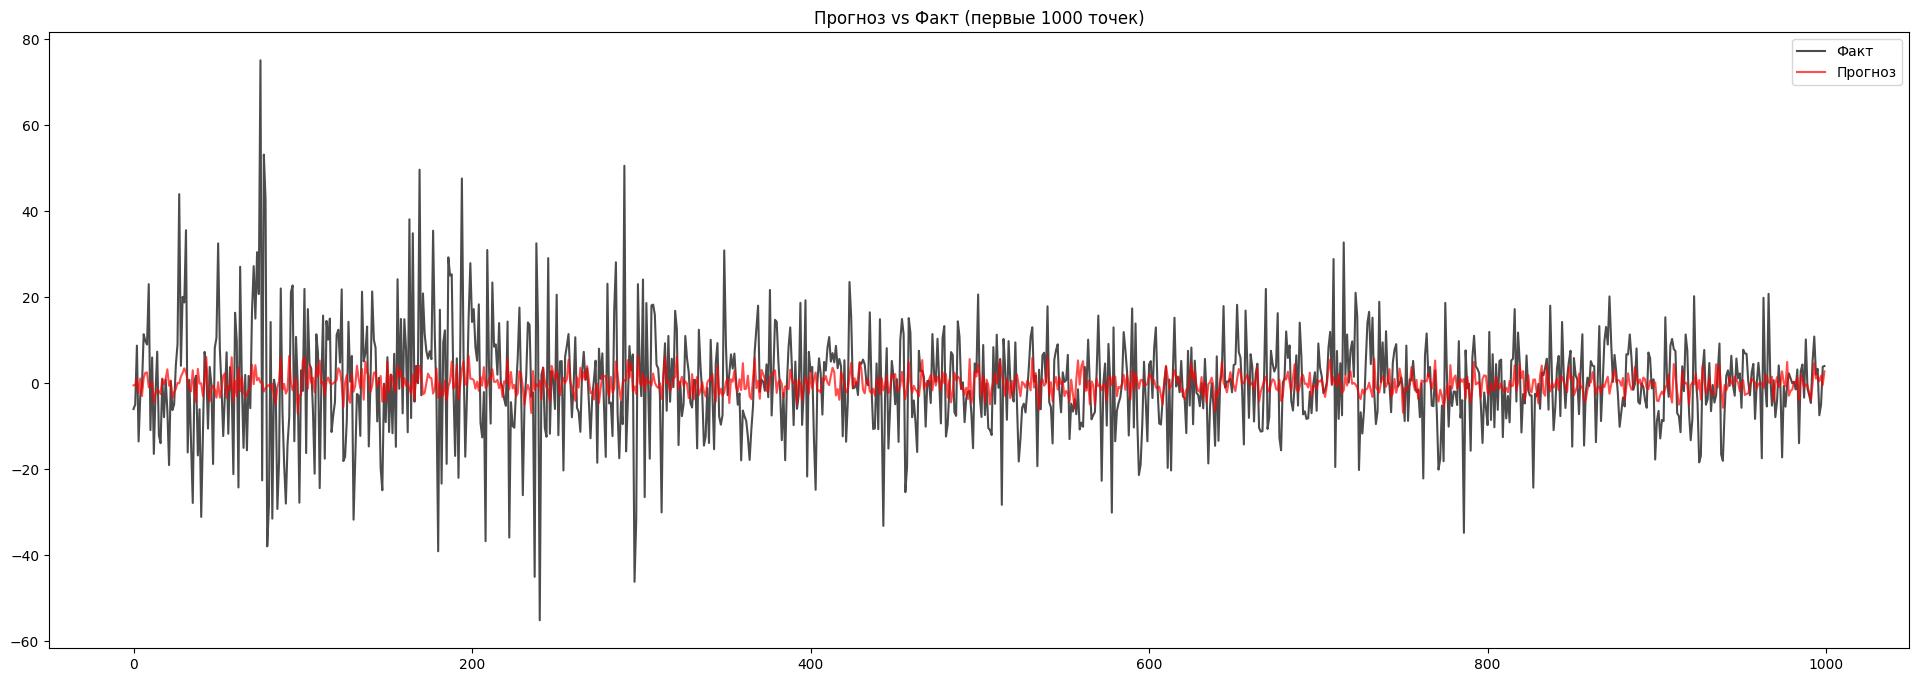

In [101]:
from src.mlcore.evaluation import evaluate_regression_model

y_pred = model.predict(X_test)

evaluate_regression_model(
    y_test=y_test,
    y_pred=y_pred,
    length=1000,
)

In [64]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Важности фичей")
for i in range(len(importance_df)):
    print(f"{importance_df.iloc[i]['importance']:.4f} | {importance_df.iloc[i]['feature']}")

Важности фичей
0.2232 | combo6_queue_pressure_sign_times_wli
0.1479 | combo11_wli_power3_div_slope_abs
0.1313 | combo30_queue_pressure_power2_times_slope_sign
0.0423 | combo4_fqi_log1p_times_wli
0.0364 | combo29_response_imbalance_log1p_times_wli
0.0328 | combo3_slope_power15
0.0318 | combo7_wli_ewm_span8_diff
0.0286 | combo46_weighted_orderbook_imb_clip_times_depth_ratio
0.0241 | combo5_strategic_fqi_sqrt_times_slope
0.0225 | combo1_wli_slope_interaction
0.0182 | combo34_depth_ratio_sqrt_times_weighted_orderbook_imb
0.0147 | combo45_response_imbalance_sqrt_times_queue_pressure_log
0.0143 | combo2_wli_abs_times_depth_pressure
0.0142 | combo35_fqi_rolling_std_18_times_slope
0.0138 | combo14_slope_sign_times_depth_pressure
0.0125 | combo40_strategic_fqi_sqrt_times_queue_pressure
0.0123 | combo47_slope_rolling_std_20_times_strategic_fqi
0.0122 | combo16_weighted_orderbook_log_times_slope
0.0119 | combo49_fqi_power1p8_times_first_queue_sign
0.0114 | combo10_first_queue_sqrt_times_strategic

### LinearRegression

In [ ]:
import torch

feature_columns = [col for col in df.columns if col not in ['price', 'target']]
X = df[feature_columns].copy()
y = df['target'].copy()

split_index = int(len(X) * 0.8)
X_train = torch.tensor(X.iloc[:split_index].to_numpy(), dtype=torch.float32)
X_test = torch.tensor(X.iloc[split_index:].to_numpy(), dtype=torch.float32)
y_train = torch.tensor(y.iloc[:split_index].to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(y.iloc[split_index:].to_numpy(), dtype=torch.float32).reshape(-1, 1)

In [ ]:
n_epochs = 20000
lr = 1e-2

long_model = LinearModel(X_train.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(long_model.parameters(), lr=lr)

for epoch in range(n_epochs):
    y_hat = long_model(X_train)
    loss = criterion(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss = loss.item()

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch: {epoch} / Loss: {train_loss:.10f}")

long_model.eval()

with torch.no_grad():
    y_pred = long_model(X_test)
    test_loss = criterion(y_pred, y_test)
    print(f"'\nTest loss: {test_loss} | Train loss: {train_loss}")

In [ ]:
import pandas as pd
from src.mlcore.evaluation import evaluate_regression_model

evaluate_regression_model(
    y_test=pd.Series(y_test.squeeze(1).numpy()),
    y_pred=pd.Series(y_pred.squeeze(1).numpy()),
    length=1000
)